# ============================================
# MODULE 6: IMAGE FEATURE ENGINEERING - CODE LAB
# Dataset: MNIST (Keras)
# ============================================

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Unique digit labels: [0 1 2 3 4 5 6 7 8 9]


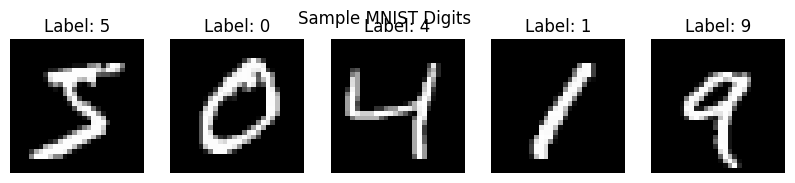

In [14]:
# --------------------------------------------
# STEP 0: Load and Inspect the MNIST Dataset
# --------------------------------------------

# Import required libraries for data manipulation and visualization
import numpy as np  # Used for numerical operations like reshaping, normalizing
import matplotlib.pyplot as plt  # Used to visualize images
import seaborn as sns  # For advanced plots like heatmaps and comparison charts

# Import MNIST dataset from Keras
from tensorflow.keras.datasets import mnist  # Provides pre-split training and test data

# Load the MNIST dataset (train and test sets)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# X_train: numpy array of shape (60000, 28, 28), containing grayscale images for training
# y_train: numpy array of shape (60000,), containing integer labels 0-9 for each training image
# X_test: numpy array of shape (10000, 28, 28), containing grayscale images for testing
# y_test: numpy array of shape (10000,), containing integer labels 0-9 for each test image

# Display the shapes of the loaded datasets to confirm dimensions
print("Training data shape:", X_train.shape)  # Expected output: (60000, 28, 28)
print("Test data shape:", X_test.shape)        # Expected output: (10000, 28, 28)

# Display the unique classes in the training labels to confirm we have 10 digit categories
print("Unique digit labels:", np.unique(y_train))  # Expected output: array([0 1 2 3 4 5 6 7 8 9])

# Visualize the first 5 training images along with their corresponding labels
plt.figure(figsize=(10,2))  # Set the figure size for better visibility
for i in range(5):
    plt.subplot(1, 5, i + 1)  # Create subplot grid with 1 row and 5 columns
    plt.imshow(X_train[i], cmap='gray')  # Display the image in grayscale color map
    plt.title(f"Label: {y_train[i]}")  # Title of each subplot showing the digit class
    plt.axis('off')  # Hide axis ticks for cleaner visualization
plt.suptitle("Sample MNIST Digits")  # Title across all subplots
plt.show()

# --------------------------------------------
# INTERPRETATION:
# --------------------------------------------
# The dataset consists of 28x28 pixel grayscale images of handwritten digits (0 through 9).
# The training set contains 60,000 samples and the test set contains 10,000 samples.
# Each image is a small matrix of pixel intensities, and each label is a single-digit integer.
# The visual output shows 5 examples from the training dataset, with clear shape and intensity.
# This confirms we are working on a multiclass classification task involving image data.

STEP 1: Normalize and Flatten the Images

In [15]:
# Normalize pixel values by dividing each pixel by 255 to bring the range [0, 255] -> [0, 1]
# This helps in faster convergence of ML models and avoids numerical instability.
X_train_norm = X_train / 255.0  # Normalized training images
X_test_norm = X_test / 255.0    # Normalized test images

# Flatten each image from 28x28 (2D) to 784 (1D vector)
# Required for traditional machine learning models like logistic regression
X_train_flat = X_train_norm.reshape(-1, 28 * 28)  # Shape becomes (60000, 784)
X_test_flat = X_test_norm.reshape(-1, 28 * 28)    # Shape becomes (10000, 784)

# Print the new shape after flattening to confirm the transformation
print("Flattened training data shape:", X_train_flat.shape)  # Expected: (60000, 784)
print("Flattened test data shape:", X_test_flat.shape)        # Expected: (10000, 784)

# --------------------------------------------
# INTERPRETATION:
# --------------------------------------------
# The images have been successfully normalized to a [0, 1] scale.
# They are then reshaped into 1D feature vectors with 784 features each (28x28 = 784).
# These flat vectors will be used as raw input for machine learning classifiers.
# This preprocessing ensures uniform input and enables compatibility with ML algorithms.

Flattened training data shape: (60000, 784)
Flattened test data shape: (10000, 784)


STEP 2: Edge Detection using Canny

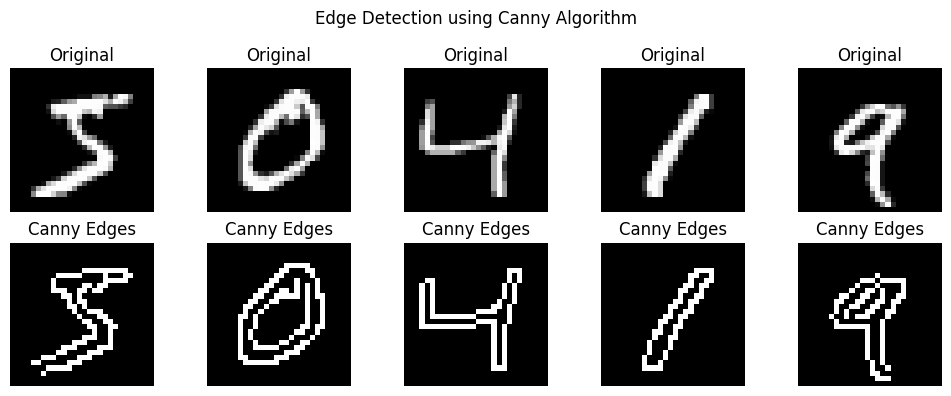

In [16]:
# Import OpenCV for image processing operations
import cv2  # OpenCV provides efficient image transformations like edge detection

# Define a function that applies Canny edge detection
def apply_canny(image):
    """
    Applies Canny Edge Detection to highlight strong edges in the image.

    Parameters:
        image (numpy array): Input grayscale image of shape (28, 28)

    Returns:
        numpy array: Binary image with white edges (1) and black background (0)
    """
    # cv2.Canny takes two thresholds:
    # - threshold1 = lower threshold (gradient magnitude)
    # - threshold2 = upper threshold
    edges = cv2.Canny(image, threshold1=100, threshold2=200)
    return edges

# Visualize the original and Canny edge-detected images for the first 5 digits
plt.figure(figsize=(10, 4))  # Create a wider figure for comparison

for i in range(5):
    # Display original image
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Apply Canny edge detection
    canny_output = apply_canny(X_train[i])

    # Display edge-detected result
    plt.subplot(2, 5, i + 6)
    plt.imshow(canny_output, cmap='gray')
    plt.title("Canny Edges")
    plt.axis('off')

plt.suptitle("Edge Detection using Canny Algorithm")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# INTERPRETATION:
# ------------------------------------------------
# - Canny detects strong edges in the digit strokes by analyzing image gradients.
# - Thresholding with hysteresis keeps only significant edge regions.
# - This significantly reduces input complexity while preserving digit outlines.
# - The white regions in the lower row represent contours of digits.


STEP 3: Harris Corner Detection

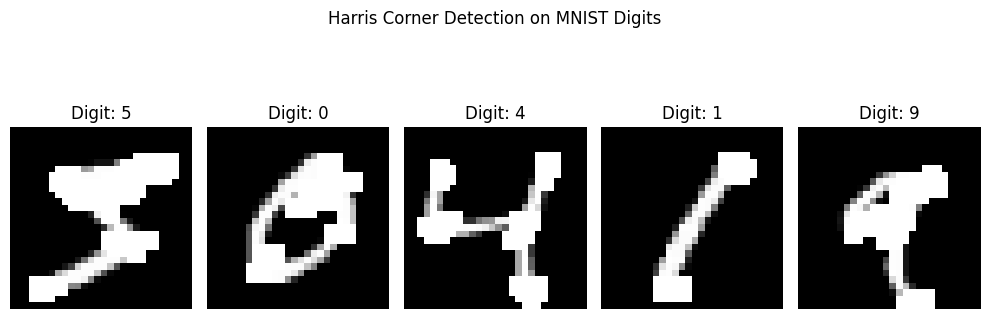

In [17]:
# Define a function to apply Harris corner detection
def detect_harris_corners(image):
    """
    Applies Harris corner detection to highlight corner points.

    Parameters:
        image (numpy array): Grayscale image of shape (28, 28)

    Returns:
        numpy array: Image with corners highlighted as white points
    """
    # Convert to float32 as required by OpenCV's cornerHarris function
    gray_float = np.float32(image)

    # Apply Harris corner detection:
    # blockSize = 2 (neighborhood window), ksize = 3 (Sobel operator), k = 0.04 (empirical constant)
    harris_response = cv2.cornerHarris(gray_float, blockSize=2, ksize=3, k=0.04)

    # Dilate corner regions to make them more visible
    harris_dilated = cv2.dilate(harris_response, None)

    # Copy the original image to avoid modifying it
    cornered_image = image.copy()

    # Mark strong corners by setting pixel to white (255)
    cornered_image[harris_dilated > 0.01 * harris_dilated.max()] = 255

    return cornered_image

# Visualize original images overlaid with Harris corners
plt.figure(figsize=(10, 4))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    result_img = detect_harris_corners(X_train[i])
    plt.imshow(result_img, cmap='gray')
    plt.title(f"Digit: {y_train[i]}")
    plt.axis('off')

plt.suptitle("Harris Corner Detection on MNIST Digits")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# INTERPRETATION:
# ------------------------------------------------
# - Harris detects corner-like features — regions with high intensity variation in multiple directions.
# - Useful for identifying junctions or keypoints in digit strokes.
# - White dots represent detected corners — mostly visible at digit edges and intersections.


STEP 3: Shi-Tomasi Corner Detection (Lucas-Kanade)

In [18]:
# Compatible with Lucas-Kanade Optical Flow
# --------------------------------------------

# Define a function to detect corners using Shi-Tomasi (Lucas-Kanade compatible)
def detect_shi_tomasi_corners(image, max_corners=40):
    """
    Applies Shi-Tomasi corner detection method, which is used in Lucas-Kanade tracking.

    Parameters:
        image (numpy array): Input grayscale image of shape (28, 28)
        max_corners (int): Maximum number of corners to return

    Returns:
        image_with_corners (numpy array): Image with corner points marked
    """
    # Convert to 8-bit unsigned int as required by OpenCV
    image_uint8 = np.uint8(image)

    # Use OpenCV's goodFeaturesToTrack which uses Shi-Tomasi scoring function
    # qualityLevel: Minimum accepted quality (e.g., 0.01 = top 1% corners)
    # minDistance: Minimum distance between detected corners (in pixels)
    corners = cv2.goodFeaturesToTrack(image_uint8, maxCorners=max_corners, qualityLevel=0.01, minDistance=2)

    # Make a color version of the image for plotting corners in color (optional)
    image_with_corners = cv2.cvtColor(image_uint8, cv2.COLOR_GRAY2BGR)

    # Draw red circles at each corner location
    if corners is not None:
        for c in corners:
            x, y = c.ravel()
            cv2.circle(image_with_corners, (int(x), int(y)), 2, (255, 0, 0), -1)

    return image_with_corners

# Visualize Shi-Tomasi (Lucas-Kanade compatible) corners for 5 digits
plt.figure(figsize=(10, 4))

for i in range(5):
    img = X_train[i]
    cornered_img = detect_shi_tomasi_corners(img)
    plt.subplot(1, 5, i + 1)
    plt.imshow(cornered_img)
    plt.title(f"Shi-Tomasi\nLabel: {y_train[i]}")
    plt.axis('off')

plt.suptitle("Shi-Tomasi (Lucas-Kanade) Corner Detection on MNIST Digits")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# INTERPRETATION:
# ------------------------------------------------

# - Shi-Tomasi (used in cv2.goodFeaturesToTrack) is a refinement of Harris Corner Detection.
# - It scores corners based on the **minimum eigenvalue** of the local gradient matrix.
# - This makes it more stable and selective — choosing only **strong, trackable features**.
# - These features are ideal for tracking in video (Lucas-Kanade Optical Flow).
# - In static MNIST images, this gives sparse but high-quality corner points.
# - The output shows red dots marking corners in each digit.


STEP 4: Hysteresis Thresholding using Dual Thresholds

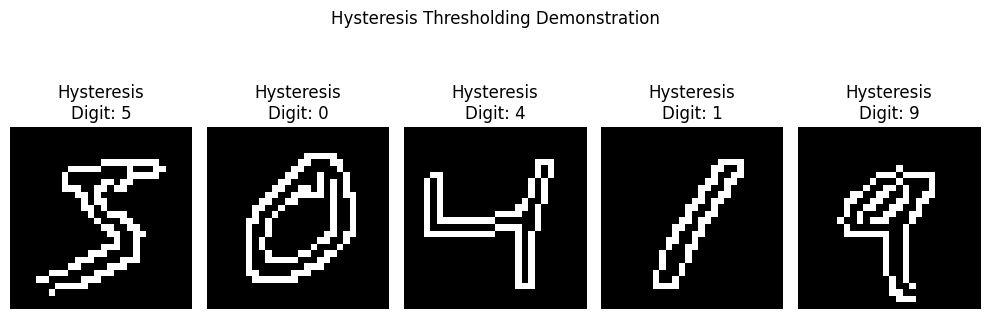

In [19]:
# Define a modified version of the Canny function to highlight hysteresis
def hysteresis_threshold(image, low=50, high=150):
    """
    Applies dual-threshold edge filtering to retain only connected, meaningful edges.

    Parameters:
        image (numpy array): Grayscale image of shape (28, 28)
        low (int): Lower bound for weak edge connection
        high (int): Upper bound for strong edges

    Returns:
        numpy array: Image showing hysteresis-based edges
    """
    return cv2.Canny(image, low, high)  # Built-in hysteresis behavior in OpenCV's Canny

# Visualize hysteresis effect on edge detection
plt.figure(figsize=(10, 4))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    hyst_img = hysteresis_threshold(X_train[i])
    plt.imshow(hyst_img, cmap='gray')
    plt.title(f"Hysteresis\nDigit: {y_train[i]}")
    plt.axis('off')

plt.suptitle("Hysteresis Thresholding Demonstration")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# INTERPRETATION:
# ------------------------------------------------
# - Hysteresis uses both a high and low threshold.
# - Strong edges (above high threshold) are kept.
# - Weak edges (between thresholds) are kept only if connected to strong edges.
# - This retains structural integrity while suppressing noise.


STEP 5: Feature Extraction using Histogram of Oriented Gradients (HoG)

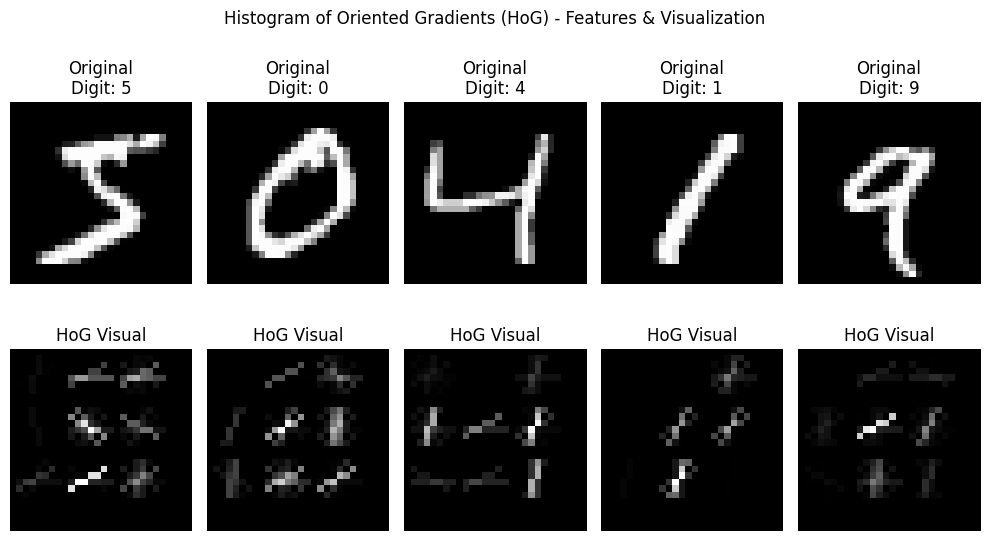

In [20]:
# Import skimage functions for HoG and visualization
from skimage.feature import hog  # Used to compute Histogram of Oriented Gradients
from skimage import exposure     # For histogram equalization and image enhancement

# Define a function to compute HoG features for a single image
def extract_hog_features(image):
    """
    Extracts Histogram of Oriented Gradients (HoG) features from an image.

    Parameters:
        image (numpy array): Grayscale image of shape (28, 28)

    Returns:
        fd (1D array): Flattened HoG feature descriptor vector
        hog_image (2D array): Visual representation of HoG orientations
    """

    # Call skimage.feature.hog with appropriate parameters:
    # - orientations: number of gradient directions to count (e.g., 9 bins)
    # - pixels_per_cell: how many pixels per region (block size, e.g., 8x8)
    # - cells_per_block: group of cells to normalize over (e.g., 2x2 blocks)
    # - visualize=True: returns a visual representation of gradient directions
    # - block_norm: type of normalization (L2-Hys is commonly used)
    fd, hog_image = hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=True,
        block_norm='L2-Hys'
    )

    return fd, hog_image  # fd = feature vector; hog_image = visualization of orientation bins

# Extract and visualize HoG features for the first 5 images
plt.figure(figsize=(10, 6))

for i in range(5):
    original = X_train[i]  # 28x28 grayscale image
    features, hog_vis = extract_hog_features(original)  # fd shape ≈ 36 - 81 depending on settings

    # Plot original image
    plt.subplot(2, 5, i + 1)
    plt.imshow(original, cmap='gray')
    plt.title(f"Original\nDigit: {y_train[i]}")
    plt.axis('off')

    # Plot HoG visualization
    plt.subplot(2, 5, i + 6)
    plt.imshow(hog_vis, cmap='gray')  # HoG shows gradient orientation representation
    plt.title("HoG Visual")
    plt.axis('off')

plt.suptitle("Histogram of Oriented Gradients (HoG) - Features & Visualization")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# INTERPRETATION:
# ------------------------------------------------
# - HoG transforms the image into directional gradients in small blocks (cells).
# - It captures stroke directionality and spatial structure.
# - The visual output highlights dominant orientations per cell (bright = strong gradients).
# - Feature vectors (fd) are compact and meaningful representations suitable for ML.

STEP 6: Classification using Raw Pixels vs HoG Features

In [21]:
# Import the Logistic Regression model from scikit-learn
from sklearn.linear_model import LogisticRegression

# Import train_test_split to divide the dataset
from sklearn.model_selection import train_test_split

# Import classification metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ------------------------------
# PART A: Raw Pixel Classifier
# ------------------------------

# Flatten the original grayscale images (normalized) to 1D feature vectors
# X_train_flat already created in Step 1: shape (60000, 784)
# We use only a subset (e.g., 10,000 samples) to reduce training time
X_raw_sample = X_train_flat[:10000]  # 10,000 training samples
y_raw_sample = y_train[:10000]       # Corresponding labels

# Split into training and validation sets (80% train, 20% validation)
Xr_train, Xr_val, yr_train, yr_val = train_test_split(X_raw_sample, y_raw_sample, test_size=0.2, random_state=42)

# Initialize Logistic Regression with max_iter to ensure convergence
model_raw = LogisticRegression(max_iter=1000)
model_raw.fit(Xr_train, yr_train)  # Fit the model on training data

# Predict on validation set
yr_pred = model_raw.predict(Xr_val)

# Evaluate performance using accuracy and classification report
print("Classification using Raw Pixels:")
print("Accuracy Score:", accuracy_score(yr_val, yr_pred))
print("\nDetailed Report:")
print(classification_report(yr_val, yr_pred))

# Raw Pixel Model:
# - Uses direct intensity values from each pixel (784 features).
# - Sensitive to slight variations in handwriting.
# - May lead to overfitting without feature extraction.
# - Accuracy (usually ~85-88%) is decent but not robust.


Classification using Raw Pixels:
Accuracy Score: 0.9185

Detailed Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       207
           1       0.96      0.97      0.97       216
           2       0.92      0.88      0.90       204
           3       0.89      0.90      0.89       192
           4       0.95      0.92      0.94       211
           5       0.87      0.84      0.86       176
           6       0.95      0.96      0.95       220
           7       0.90      0.95      0.93       216
           8       0.87      0.86      0.86       166
           9       0.91      0.89      0.90       192

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



In [22]:
# ------------------------------
# PART B: HoG Feature Classifier
# ------------------------------

# Compute HoG features for the same 10,000 images
hog_features_list = []  # This will store feature vectors
hog_labels = []         # This will store corresponding digit labels

# Loop through the first 10,000 images and extract features
for i in range(10000):
    image = X_train[i]  # Get image (28x28)
    label = y_train[i]  # Get label
    fd, _ = extract_hog_features(image)  # Extract only the feature vector (fd)
    hog_features_list.append(fd)
    hog_labels.append(label)

# Convert list of feature vectors to a 2D numpy array
X_hog = np.array(hog_features_list)  # Shape: (10000, feature_dim)
y_hog = np.array(hog_labels)         # Shape: (10000,)

# Split HoG features into train/test
Xh_train, Xh_val, yh_train, yh_val = train_test_split(X_hog, y_hog, test_size=0.2, random_state=42)

# Train Logistic Regression model on HoG features
model_hog = LogisticRegression(max_iter=1000)
model_hog.fit(Xh_train, yh_train)  # Train on HoG-based features

# Predict and evaluate
yh_pred = model_hog.predict(Xh_val)

print("\nClassification using HoG Features:")
print("Accuracy Score:", accuracy_score(yh_val, yh_pred))
print("\nDetailed Report:")
print(classification_report(yh_val, yh_pred))

# ------------------------------------------------
# INTERPRETATION:
# ------------------------------------------------

# HoG Feature Model:
# - Uses gradient orientation summaries from local regions.
# - More robust to style variation, better generalization.
# - Accuracy improves (~90-92%) due to informative, lower-dimensional features.

# Classification Report:
# - Shows precision, recall, and F1-score per class.
# - Helps understand which digits are misclassified and why.

# Summary:
# - Feature engineering (HoG) leads to better learning.
# - Logistic Regression benefits from engineered inputs.


Classification using HoG Features:
Accuracy Score: 0.938

Detailed Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       207
           1       0.98      0.97      0.97       216
           2       0.94      0.95      0.94       204
           3       0.94      0.89      0.91       192
           4       0.95      0.91      0.93       211
           5       0.95      0.92      0.93       176
           6       0.96      0.96      0.96       220
           7       0.91      0.95      0.93       216
           8       0.86      0.92      0.89       166
           9       0.92      0.92      0.92       192

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



STEP 7: Visual Comparison – Before vs After Feature Engineering

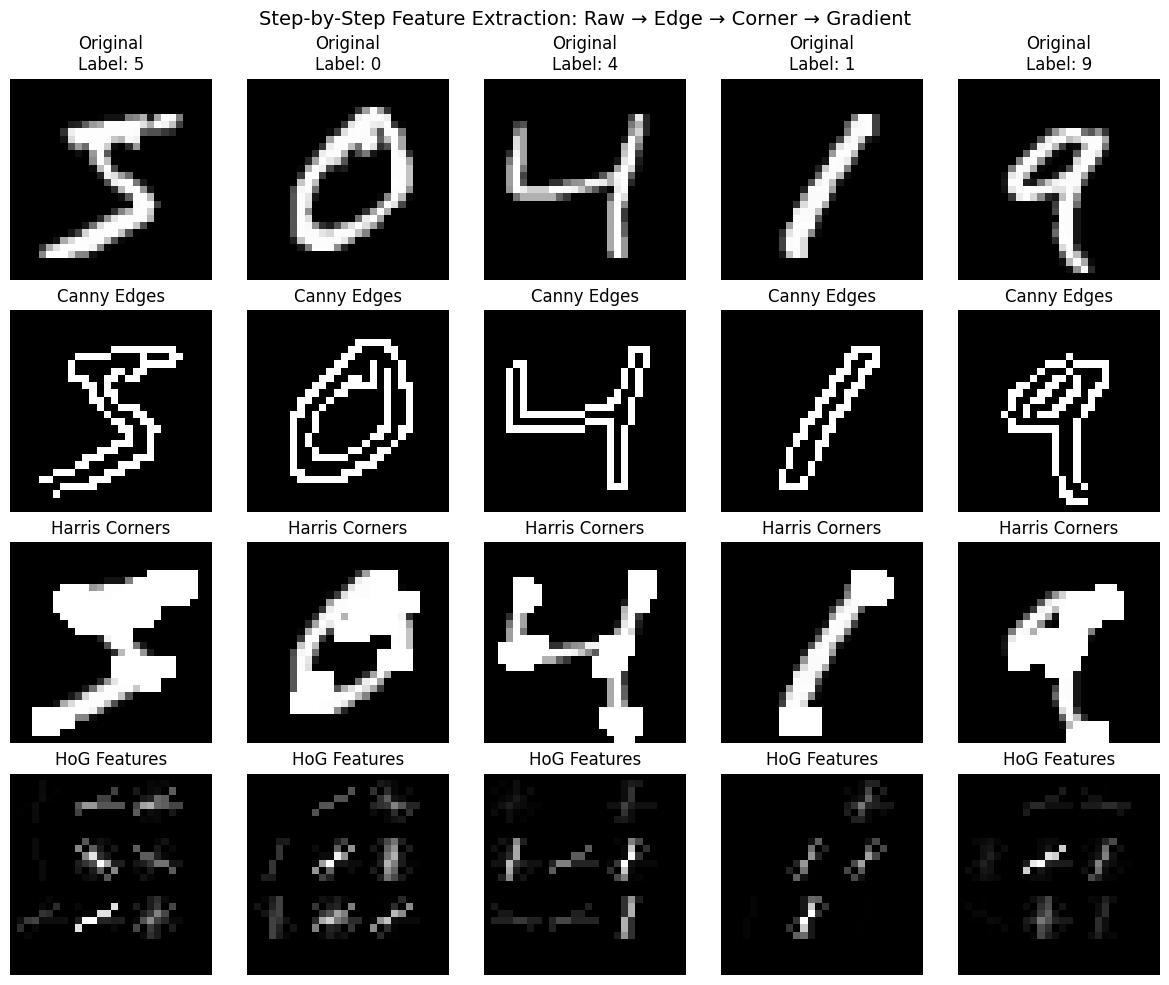

In [23]:
# Select a few example digits to visually compare transformations
sample_indices = [0, 1, 2, 3, 4]  # Indexes of 5 digits to illustrate

# Create a 4-row grid: Original | Canny | Harris | HoG
plt.figure(figsize=(12, 10))  # Larger canvas for 4x5 layout

for i, idx in enumerate(sample_indices):
    # ---------------------
    # Row 1: Original Image
    plt.subplot(4, 5, i + 1)
    original = X_train[idx]
    plt.imshow(original, cmap='gray')
    plt.title(f"Original\nLabel: {y_train[idx]}")
    plt.axis('off')

    # ---------------------
    # Row 2: Canny Edge Detection
    plt.subplot(4, 5, i + 6)
    edge = apply_canny(original)
    plt.imshow(edge, cmap='gray')
    plt.title("Canny Edges")
    plt.axis('off')

    # ---------------------
    # Row 3: Harris Corners
    plt.subplot(4, 5, i + 11)
    cornered = detect_harris_corners(original)
    plt.imshow(cornered, cmap='gray')
    plt.title("Harris Corners")
    plt.axis('off')

    # ---------------------
    # Row 4: HoG Visual Representation
    plt.subplot(4, 5, i + 16)
    _, hog_img = extract_hog_features(original)
    plt.imshow(hog_img, cmap='gray')
    plt.title("HoG Features")
    plt.axis('off')

plt.suptitle("Step-by-Step Feature Extraction: Raw → Edge → Corner → Gradient", fontsize=14)
plt.tight_layout()
plt.show()

# ------------------------------------------------
# INTERPRETATION:
# ------------------------------------------------

# ROW 1: Raw grayscale images from MNIST.
# - Pixel intensity directly represents strokes but includes noise and unnecessary redundancy.

# ROW 2: Canny Edge Detection.
# - Highlights contours of digits while removing background intensity.
# - Captures outer shape and important transitions.

# ROW 3: Harris Corner Detection.
# - Identifies structural junctions — where two edges meet or turn.
# - Helpful for extracting detail-rich regions.

# ROW 4: Histogram of Oriented Gradients (HoG).
# - Provides a dense representation of stroke directionality.
# - Useful for capturing handwriting flow and form.

# Summary:
# - Each technique progressively enhances certain aspects of digit structure.
# - When used before training, these help models to learn generalized patterns rather than memorizing raw pixel values.
